https://www.kaggle.com/code/yashhvyass/adult-census-income-logistic-reg-explained-86-2

In [81]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# **0. CONTEXTUALIZACIÓN**

- Objetivo de estudio:

    Predecir si una persona ganará más o menos de 50000 USD al año según sus datos demográficos y socioeconómicos de una persona adulta. En base a esos resultados, se desarrollará un sistema de recomendación interpretativo, capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingresos.

- Variables de estudio: 
    - age: la edad de un individuo
    - workclass: un término general para representar el estado laboral de un individuo
    - fnlwgt: peso final. Este es el número de personas que el censo cree que la entrada representa.
    - education: el nivel más alto de educación alcanzado por un individuo
    - education_num: el nivel más alto de educación alcanzado en forma numérica
    - marital_status: estado civil de un individuo
    - occupation: el tipo general de ocupación de un individuo
    - relationship: representa qué es este individuo en relación con otros
    - race: descripciones de la raza de un individuo
    - sex: el sexo del individuo
    - capital_gain: ganancias de capital de un individuo
    - capital_loss: pérdidas de capital de un individuo
    - hours_per_week: las horas que un individuo ha reportado trabajar por semana
    - native_country: país de origen de un individuo

# **1. CARGA Y PROCESAMIENTO DE DATOS**

In [82]:
df=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv')

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [84]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 1.1. Limpieza de datos

### A) Valores unicos y duplicados

In [85]:
#Valores unicos
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


In [86]:
#Valores duplicados por filas
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 24 filas duplicadas


In [87]:
#Mostramos un df con todas las filas duplicadas
todas=df.duplicated(keep=False)
df.iloc[todas[todas==True].index].sort_values(by="fnlwgt").T

,29334,26531,11121,23276,23827,10357,6227,8645,19622,20507,...,9067,28796,11777,27133,7978,8453,19832,23720,18906,32419
age,39,39,49,49,49,49,90,90,19,19,...,27,27,28,28,25,25,44,44,35,35
workclass,Private,Private,Private,Private,Self-emp-not-inc,Self-emp-not-inc,Private,Private,Private,Private,...,Private,Private,Private,Private,Private,Private,Private,Private,Private,Private
fnlwgt,30916,30916,31267,31267,43479,43479,52386,52386,97261,97261,...,255582,255582,274679,274679,308144,308144,367749,367749,379959,379959
education,HS-grad,HS-grad,7th-8th,7th-8th,Some-college,Some-college,Some-college,Some-college,HS-grad,HS-grad,...,HS-grad,HS-grad,Masters,Masters,Bachelors,Bachelors,Bachelors,Bachelors,HS-grad,HS-grad
education.num,9,9,4,4,10,10,10,10,9,9,...,9,9,14,14,13,13,13,13,9,9
marital.status,Married-civ-spouse,Married-civ-spouse,Married-civ-spouse,Married-civ-spouse,Married-civ-spouse,Married-civ-spouse,Never-married,Never-married,Never-married,Never-married,...,Never-married,Never-married,Never-married,Never-married,Never-married,Never-married,Never-married,Never-married,Divorced,Divorced
occupation,Craft-repair,Craft-repair,Craft-repair,Craft-repair,Craft-repair,Craft-repair,Other-service,Other-service,Farming-fishing,Farming-fishing,...,Machine-op-inspct,Machine-op-inspct,Prof-specialty,Prof-specialty,Craft-repair,Craft-repair,Prof-specialty,Prof-specialty,Other-service,Other-service
relationship,Husband,Husband,Husband,Husband,Husband,Husband,Not-in-family,Not-in-family,Not-in-family,Not-in-family,...,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family,Not-in-family
race,White,White,White,White,White,White,Asian-Pac-Islander,Asian-Pac-Islander,White,White,...,White,White,White,White,White,White,White,White,White,White
sex,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,...,Female,Female,Male,Male,Male,Male,Female,Female,Female,Female


In [88]:
#Eliminamos las filas duplicadas
df.drop_duplicates(keep="last", inplace=True)
## Verificamos que se han eliminado correctamente
fil_dup=df.duplicated(keep="last") #Fila duplicada ultima aparicion
print("Ya no hay filas duplicadas" if fil_dup.sum()==0 else f"Todavía hay {fil_dup.sum()} filas duplicadas")

Ya no hay filas duplicadas


In [89]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


### B) Valores anómalos

In [90]:
#Procesamiento xi numericas
df.select_dtypes(exclude="object").describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Podemos observar como de la variable numérica `capital.gain` presenta riesgo de valores faltantes enmascarados porque la gran mayoria de sus observaciones son nulas y su máximo dista mucho del resto de la distribución. Además, `hours.per.week` deberá ser analizada por la presencia de observaciones con valores excesivamente altos.

In [91]:
df[df['capital.gain']>=df['capital.gain'].max()].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,159.000000,159.000000,159.000000,159.0,159.0,159.000000
mean,46.358491,192968.886792,12.918239,99999.0,0.0,49.798742
std,10.899009,101598.198627,2.477669,0.0,0.0,12.450804
min,21.000000,25468.000000,5.000000,99999.0,0.0,20.000000
25%,39.000000,120529.000000,10.500000,99999.0,0.0,40.000000
50%,47.000000,175642.000000,13.000000,99999.0,0.0,50.000000
75%,52.000000,236533.500000,15.000000,99999.0,0.0,60.000000
max,78.000000,553405.000000,16.000000,99999.0,0.0,80.000000


Parece que estos valores son al azar pues no observamos ningun patrón oculto en los datos, auqnue este caso será estudiado en detenimiendo en la fase de ingeniería de características.

In [92]:
df[df['hours.per.week']>=df['hours.per.week'].max()].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.0
mean,43.517647,161462.129412,10.611765,799.529412,125.717647,99.0
std,13.339533,103387.089190,3.415978,2932.860012,508.916838,0.0
min,19.000000,24790.000000,4.000000,0.000000,0.000000,99.0
25%,34.000000,89681.000000,9.000000,0.000000,0.000000,99.0
50%,42.000000,158712.000000,10.000000,0.000000,0.000000,99.0
75%,51.000000,208826.000000,13.000000,0.000000,0.000000,99.0
max,90.000000,511289.000000,16.000000,15024.000000,2415.000000,99.0


Parece que estos valores son al azar pues no observamos ningun patrón oculto en los datos, por lo que procedemos a imputarlos como valores faltantes.

In [93]:
#Vericamos reemplazo
df['hours.per.week'].replace({float(99.0): np.nan}, inplace=True)
print(f'Numero de valores faltantes enmascarados: {df['hours.per.week'].isna().sum()} observaciones')

Numero de valores faltantes enmascarados: 85 observaciones


C:\Users\Usuario\AppData\Local\Temp\ipykernel_14344\2016826101.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['hours.per.week'].replace({float(99.0): np.nan}, inplace=True)


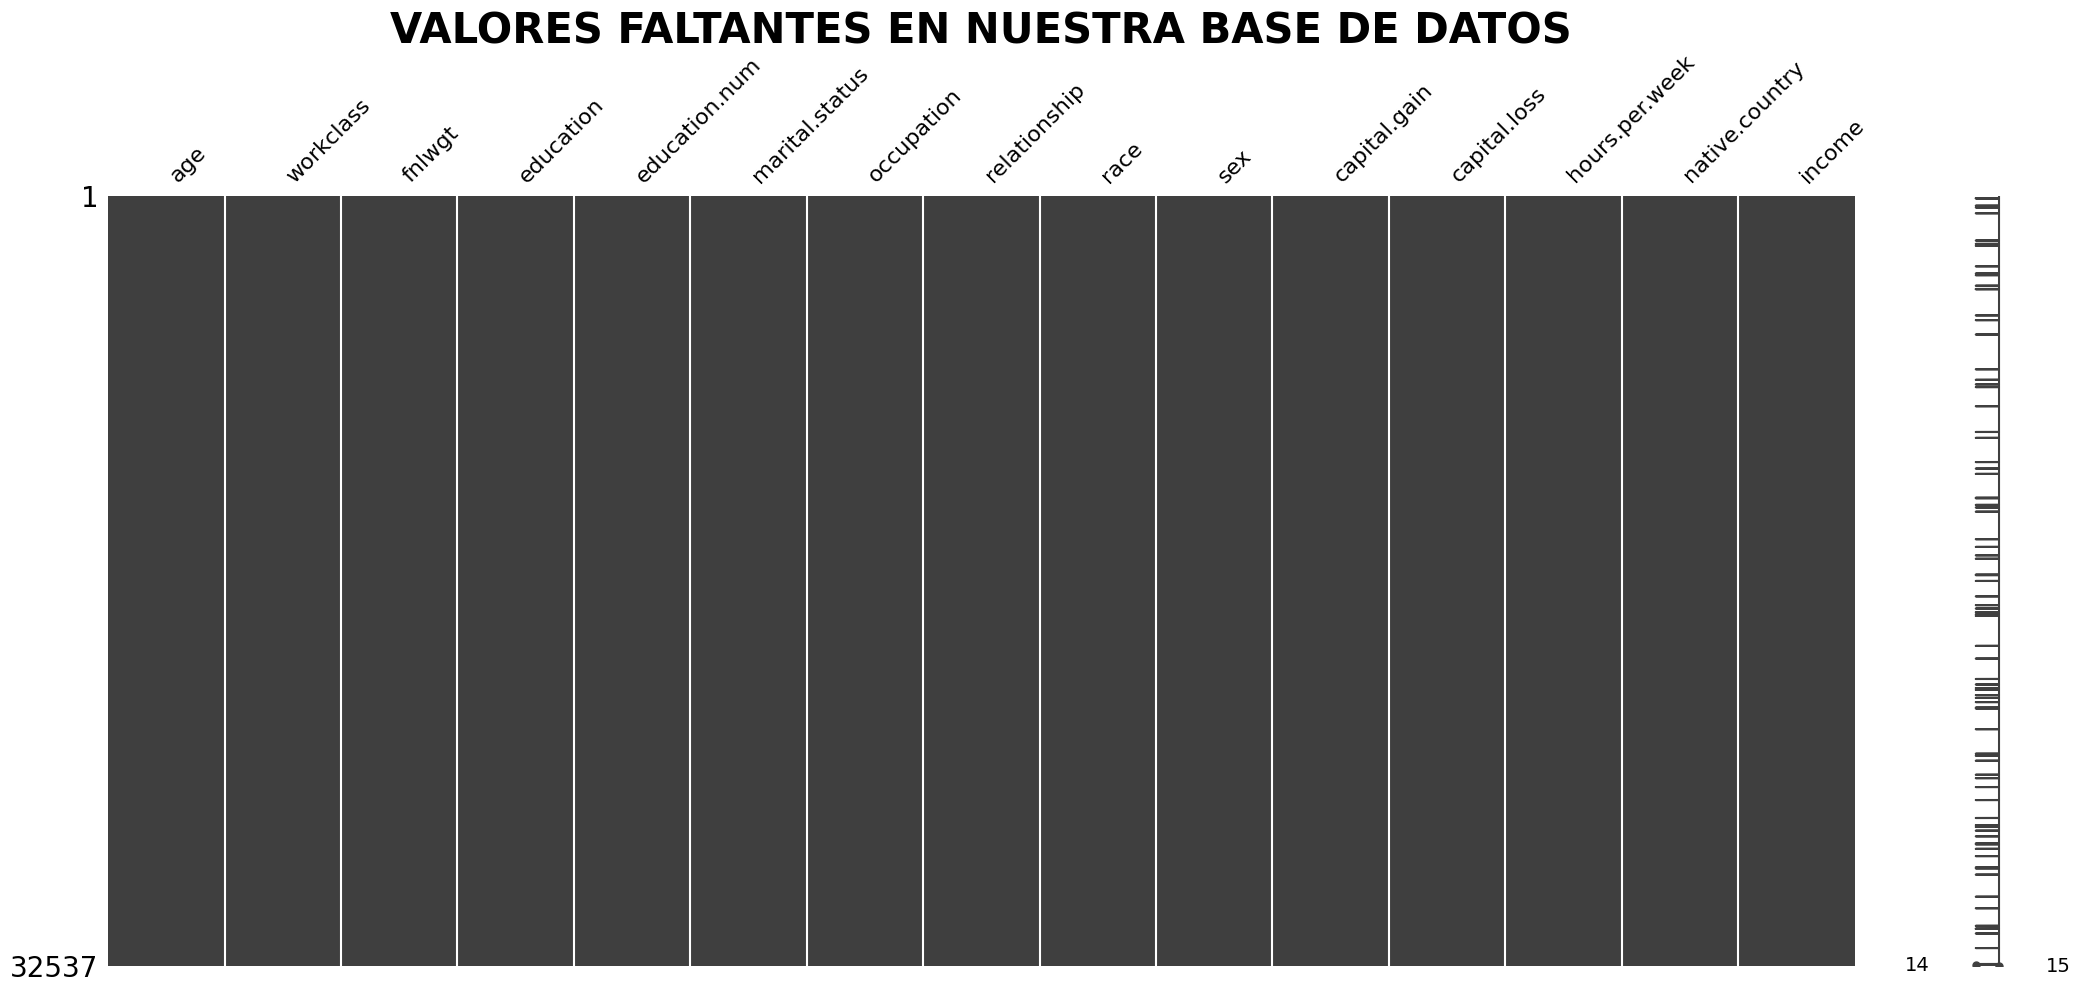

In [94]:
#Visualización final
msno.matrix(df)
plt.title("Valores faltantes en nuestra base de datos".upper(), fontweight="bold", fontsize=30)
plt.show()

## 1.2. Transformación de datos

In [95]:
#Procesamiento yi
df['income'].value_counts(normalize=True).round(5)

income
<=50K    0.75907
>50K     0.24093
Name: proportion, dtype: float64

In [96]:
#Mapeamos los valores
df['income']=df['income'].map({'<=50K': 0, '>50K': 1}).astype('Int64')
#Renombramos la variable
df.rename(columns={'income': 'inc_50'}, inplace=True)

In [98]:
#Procesamiento xi categoricas
for var in df.select_dtypes(include="object"):
    print(f"Variable '{var}'")
    print(df[var].unique())
    print('-'*30)

Variable 'workclass'
['?' 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']
------------------------------
Variable 'education'
['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']
------------------------------
Variable 'marital.status'
['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
------------------------------
Variable 'occupation'
['?' 'Exec-managerial' 'Machine-op-inspct' 'Prof-specialty'
 'Other-service' 'Adm-clerical' 'Craft-repair' 'Transport-moving'
 'Handlers-cleaners' 'Sales' 'Farming-fishing' 'Tech-support'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
------------------------------
Variable 'relationship'
['Not-in-family' 'Unmarried' 'Own-child' 'Other-relative' 'Husband' 'Wife']
------------------------------
Variable

In [99]:
#Eliminamos los valores faltantes
df.replace("?", pd.NA, inplace=True)
df.dropna(inplace=True)

## 1.3. Estandariación de las variables

In [100]:
# Variable selection and preprocessing
features = ['age', 'education', 'marital.status', 'occupation', 'hours.per.week', 'sex', 'native.country']
X = df[features]
y = df['inc_50']

numeric_features = ['age', 'hours.per.week']
categorical_features = ['education', 'marital.status', 'occupation', 'sex', 'native.country']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [101]:
# Selección de variables y configuración del preprocesado
# Columnas de entrada del modelo
features = ['age', 'education', 'marital.status', 'occupation', 'hours.per.week', 'sex', 'native.country']
X = df[features]
# Define y como la variable objetivo binaria (1 si >50K, 0 si <=50K)
y = df['inc_50']

# Variables numéricas a las que se aplicará escalado (normalización)
carac_num= ['age', 'hours.per.week']
# Categóricas que se convertirán en variables dummy (one-hot)
cat_num = ['education', 'marital.status', 'occupation', 'sex', 'native.country']

# Escalado variables numéricas (media 0, desviación 1)
esc_num = StandardScaler()
# Configuración encorder
esc_cat = OneHotEncoder(handle_unknown='ignore') #ignora valores desconocidos

# Combina los transformadores en un ColumnTransformer para aplicarlos por columna
preprocessor = ColumnTransformer(
    # Define la lista de transformadores que se aplicarán
    transformers=[
        # Asigna el escalador a las columnas numéricas
        ("num", esc_num, carac_num),
        # Asigna el codificador one-hot a las columnas categóricas
        ("cat", esc_cat, cat_num),
    ]
)

# **2. ENTRENAMIENTO**

In [102]:
# Configuración del Pipeline para predecir si se cobra mas o menos de 50k
model = Pipeline(steps=[
    ('preprocessor', preprocessor), #Se indica los procesadores anteriores
    ('classifier', LogisticRegression(max_iter=1000)) #Se determina el modelo a utilizar
])

# Entrenamiento del modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [113]:
x=pd.DataFrame([{
    "age": 25,
    "education": "HS-grad",
    "marital.status": "Never-married",
    "occupation": "Sales",
    "hours.per.week": 30,
    "sex": "Male",
    "native.country": "United-States"
}])

model.predict_proba(x)[0][1]

np.float64(0.018514971520559302)

In [114]:
#Sistema de recomendacion
def sist_recom(usuario, modelo):
    '''
    Funcion que captura la probabilidad estimada anterior

    - Input: edad, educacion, estado civil, ocupacion, horas trabajadas, sexo, pais origen
    '''
    #Transformamos entrada para predecir
    input=pd.DataFrame([usuario])
    #Extraemos la prediccion y la probabilidad de pertenecer a cada grupo
    pred=modelo.predict(input)
    prob=modelo.predict_proba(input)[0][1]
    #Clave: condicional para recomendar si estudiar o cambiar de trabajo
    return f'Con este perfil, la probabilidad de ganar más de 50k es {round(prob*100,2)}%' if pred==1 else f'Con este perfil, la probabilidad de ganar más de 50k es baja ({round(prob*100,2)}%). Considere ampliar sus skills o buscar un nuevo trabajo'

In [120]:
# User simulation
simulated_user = {
    "age": 23,
    "education": "HS-grad",
    "marital.status": "Never-married",
    "occupation": "Sales",
    "hours.per.week": 35,
    "sex": "Male",
    "native.country": "Peru"
}
sist_recom(simulated_user, model)

'Con este perfil, la probabilidad de ganar más de 50k es baja (1.19%). Considere ampliar sus skills o buscar un nuevo trabajo'